In [ ]:
import numpy as np
import scipy.io as sio

from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

In [ ]:
from google.colab import files
uploaded = files.upload()


Saving MyoGym.mat to MyoGym.mat


# **Caricamento DATASET (utilizzo features già calcolate)**

In [ ]:
data = sio.loadmat('MyoGym.mat')

accF  = data['features_acc']
gyroF = data['features_gyro']
labels = data['features_labels']

y_all = labels[:,0].astype(int).ravel()
subjects = labels[:,1].astype(int).ravel()


In [ ]:
print(accF.shape)
print(gyroF.shape)
print(y_all.shape)
print(subjects.shape)
X = np.hstack([accF, gyroF])
print(X.shape)

(40253, 57)
(40253, 57)
(40253,)
(40253,)
(40253, 114)


In [ ]:
# Scelgo tutte le classi senza la classe NULL
classes_keep = []
for i in range(1, 31,1):
  classes_keep.append(i)

print(classes_keep)

# creo maschera che contiene valori True (1) dove la label è una delle classes_keep
mask = np.isin(y_all, classes_keep)

X = np.hstack([accF[mask], gyroF[mask]])  # concateno le feature acc + gyro
y = y_all[mask]                           # prendo solo le label delle classi di interesse
s = subjects[mask]                        # prendo solo i soggetti delle classi di interesse


[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30]


In [ ]:
print(y_all)
print(mask)
print(X.shape)
print(y.shape)
print(s.shape)

[99 99 99 ... 99 99 99]
[False False False ... False False False]
(9243, 114)
(9243,)
(9243,)


#**Addestramento Modello**

In [ ]:
# Per addestrare il modello uso tecnica LOSO (Leave-One-Subject-Out),
# che consiste nel testare il modello sui dati di un singolo soggetto, dopo averlo addestrato con i dati di tutti gli altri.

unique_subjects = np.unique(s)  # uso ogni soggetto come test set, allenando il modello con tutti gli altri

y_true = []
y_pred = []

# ciclo su ogni soggetto
for sub in unique_subjects:
    test_idx = (s == sub) # creo vettore con valori True quando i dati sono del soggetto specifico (sub)
    train_idx = ~test_idx # inverto la maschera -> uso gli altri dati degli altri soggetti come train set
                          # seleziono tutti i dati tranne quelli del soggetto corrente

    Xtr, Xte = X[train_idx], X[test_idx]
    ytr, yte = y[train_idx], y[test_idx]

    # Standardizzazione (fit solo su train), metto tutte le feature sulla stessa scala
    scaler = StandardScaler()
    Xtr = scaler.fit_transform(Xtr) # calcola la media e dev_std per il train set e normalizza
    Xte = scaler.transform(Xte) # usa stessa normalizzazione sul test set

    # Random Forest (baseline robusta)
    #clf = RandomForestClassifier(
     #   n_estimators=200,
     #   min_samples_leaf=5,
     #   n_jobs=-1,
    #    random_state=42
    #)
    #clf.fit(Xtr, ytr)

    # KNN
    #clf = KNeighborsClassifier(
    #    n_neighbors=15,
    #    weights="distance",        # meglio di uniform
    #    metric="minkowski", p=2    # p=2 => euclidea
    #)

    # SVM
    clf = SVC(
        kernel="rbf",
        C=1.0, gamma="scale",
        class_weight="balanced"
    )

    clf.fit(Xtr, ytr)
    pred = clf.predict(Xte)

    y_true.append(yte)
    y_pred.append(pred)

    print(f"Subject {sub} done. Test samples: {len(yte)}")

y_true = np.concatenate(y_true)
y_pred = np.concatenate(y_pred)


Subject 1 done. Test samples: 1055
Subject 2 done. Test samples: 1184
Subject 3 done. Test samples: 788
Subject 4 done. Test samples: 736
Subject 5 done. Test samples: 984
Subject 6 done. Test samples: 982
Subject 7 done. Test samples: 918
Subject 8 done. Test samples: 822
Subject 9 done. Test samples: 1090
Subject 10 done. Test samples: 684


In [ ]:
print(y_pred.shape)
print(y_pred)
print(y_true.shape)
print(y_true)

(9243,)
[ 1  1  1 ... 30 30 30]
(9243,)
[ 1  1  1 ... 30 30 30]


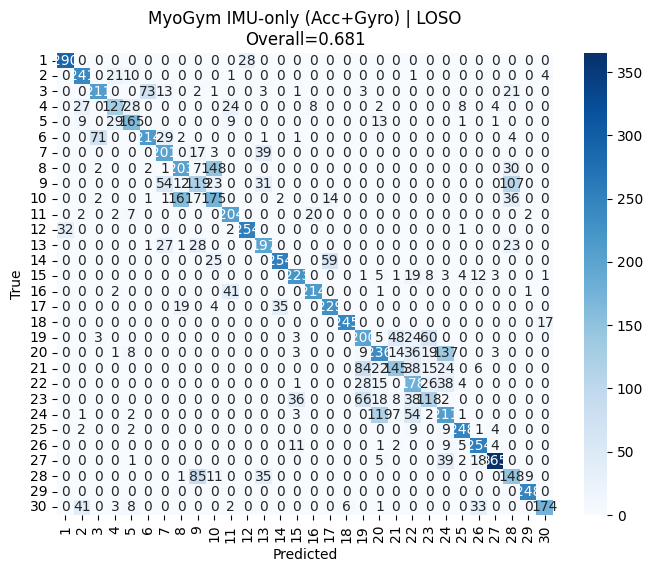

Classification Report:

              precision    recall  f1-score   support

           1       0.90      0.91      0.91       318
           2       0.75      0.87      0.80       278
           3       0.73      0.64      0.68       328
           4       0.69      0.56      0.62       228
           5       0.71      0.73      0.72       227
           6       0.74      0.66      0.70       322
           7       0.62      0.77      0.69       260
           8       0.51      0.52      0.51       393
           9       0.45      0.34      0.39       346
          10       0.45      0.44      0.44       399
          11       0.72      0.86      0.78       237
          12       0.90      0.88      0.89       289
          13       0.64      0.71      0.68       277
          14       0.87      0.75      0.81       338
          15       0.79      0.80      0.79       280
          16       0.88      0.83      0.85       259
          17       0.76      0.80      0.78       287
   

In [ ]:
# Overall accuracy


classes = np.unique(y_true)

cm = confusion_matrix(y_true, y_pred, labels=classes)
report = classification_report(y_true, y_pred, labels=classes)
acc_overall = accuracy_score(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes,
            yticklabels=classes)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title(f"MyoGym IMU-only (Acc+Gyro) | LOSO\nOverall={acc_overall:.3f}")
plt.show()

# Report di classificazione
print("Classification Report:\n")
print(report)


# **Eliminazione delle classi problematiche ( Esercizi con cinematica simile e classi Curl)**

In [ ]:
# SOLO esercizi (NO NULL)
classes_keep = [1, 6, 7, 11, 12, 14, 15, 16, 17, 18, 25, 26, 27, 29, 30]
#classes_keep = [1, 6, 7, 12, 15, 18, 27, 29]  # prestazioni migliori


mask = np.isin(y_all, classes_keep)

X = np.hstack([accF[mask], gyroF[mask]])
y = y_all[mask]
s = subjects[mask]


In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.metrics import classification_report, confusion_matrix
from  sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

unique_subjects = np.unique(s)

y_true = []
y_pred = []

for sub in unique_subjects:
    test_idx = (s == sub)
    train_idx = ~test_idx

    Xtr, Xte = X[train_idx], X[test_idx]
    ytr, yte = y[train_idx], y[test_idx]

    scaler = StandardScaler()
    Xtr = scaler.fit_transform(Xtr)
    Xte = scaler.transform(Xte)

    #clf = KNeighborsClassifier(
    #    n_neighbors=15,
    #    weights="distance",        # meglio di uniform
    #    metric="minkowski", p=2    # p=2 => euclidea
    #)
    #clf.fit(Xtr, ytr)

    # Random Forest (baseline robusta)
    #clf = RandomForestClassifier(
     #   n_estimators=200,
     #   min_samples_leaf=5,
     #   n_jobs=-1,
     #   random_state=42
    #)
    #clf.fit(Xtr, ytr)

    # SVM
    clf = SVC(kernel="rbf",
              C=1.0, gamma="scale",
              class_weight="balanced")
    clf.fit(Xtr, ytr)

    pred = clf.predict(Xte)

    y_true.append(yte)
    y_pred.append(pred)

    print(f"Subject {sub} done. Test samples: {len(yte)}")

y_true = np.concatenate(y_true)
y_pred = np.concatenate(y_pred)


Subject 1 done. Test samples: 493
Subject 2 done. Test samples: 562
Subject 3 done. Test samples: 389
Subject 4 done. Test samples: 349
Subject 5 done. Test samples: 463
Subject 6 done. Test samples: 447
Subject 7 done. Test samples: 421
Subject 8 done. Test samples: 381
Subject 9 done. Test samples: 508
Subject 10 done. Test samples: 346


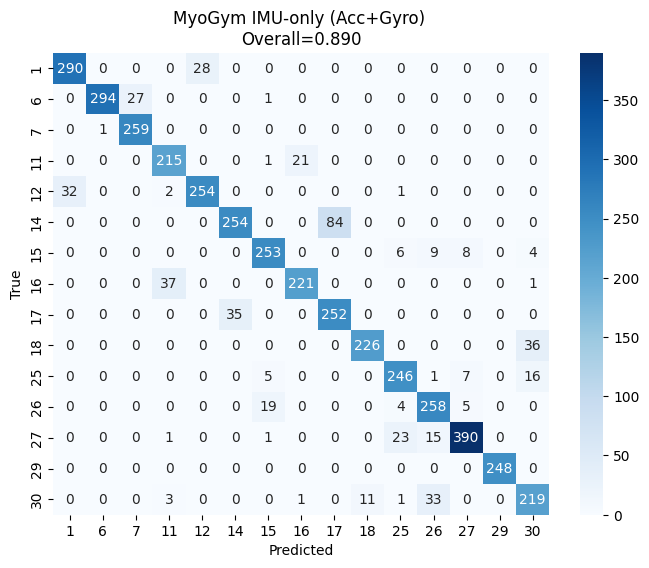

Classification Report:

              precision    recall  f1-score   support

           1       0.90      0.91      0.91       318
           6       1.00      0.91      0.95       322
           7       0.91      1.00      0.95       260
          11       0.83      0.91      0.87       237
          12       0.90      0.88      0.89       289
          14       0.88      0.75      0.81       338
          15       0.90      0.90      0.90       280
          16       0.91      0.85      0.88       259
          17       0.75      0.88      0.81       287
          18       0.95      0.86      0.91       262
          25       0.88      0.89      0.88       275
          26       0.82      0.90      0.86       286
          27       0.95      0.91      0.93       430
          29       1.00      1.00      1.00       248
          30       0.79      0.82      0.81       268

    accuracy                           0.89      4359
   macro avg       0.89      0.89      0.89      4359
we

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

acc_overall = accuracy_score(y_true, y_pred)
classes = np.unique(y_true)
cm = confusion_matrix(y_true, y_pred, labels=classes)
report = classification_report(y_true, y_pred, labels=classes)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes,
            yticklabels=classes)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title(f"MyoGym IMU-only (Acc+Gyro) \nOverall={acc_overall:.3f}")
plt.show()

print("Classification Report:\n")
print(report)


# **Inferenza**

In [ ]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

# Scegliamo un soggetto test
test_subject = np.random.choice(np.unique(s))

test_idx = (s == test_subject)
train_idx = ~test_idx

Xtr, Xte = X[train_idx], X[test_idx]
ytr, yte = y[train_idx], y[test_idx]

print(f"Test subject: {test_subject}")
print(f"Train samples: {Xtr.shape[0]}, Test samples: {Xte.shape[0]}")


# Standardizzazione CORRETTA
scaler = StandardScaler()
Xtr_std = scaler.fit_transform(Xtr)
Xte_std = scaler.transform(Xte)


# Train classificatore
clf = SVC(kernel="rbf",
              C=1.0, gamma="scale",
              class_weight="balanced",
              probability=True)
clf.fit(Xtr_std, ytr)


# Estrazione di UNA feature casuale dal test
idx_random = np.random.randint(0, Xte_std.shape[0])

x_new = Xte_std[idx_random].reshape(1, -1)
y_true = yte[idx_random]


# Inferenza
y_pred = clf.predict(x_new)[0]
y_prob = clf.predict_proba(x_new)[0]

print("\n--- INFERENZA  ---")
print(f"True label:      {y_true}")
print(f"Predicted label: {y_pred}")


# Probabilità per classe
classes = clf.classes_
print("\nClass probabilities:")
for c, p in zip(classes, y_prob):
    print(f"  Class {c}: {p:.3f}")

Test subject: 6
Train samples: 3912, Test samples: 447

--- INFERENZA  ---
True label:      6
Predicted label: 6

Class probabilities:
  Class 1: 0.001
  Class 6: 0.972
  Class 7: 0.005
  Class 11: 0.001
  Class 12: 0.005
  Class 14: 0.002
  Class 15: 0.005
  Class 16: 0.000
  Class 17: 0.002
  Class 18: 0.001
  Class 25: 0.001
  Class 26: 0.002
  Class 27: 0.002
  Class 29: 0.001
  Class 30: 0.001


# **Aggiunta classe Curl**
Accorpando tutte le classi relative agli esercizi Curl, il dataset si sbilancia

In [ ]:
# classi originali da tenere
classes_keep = [1, 6, 7, 11, 12, 14, 15, 16, 17, 18, 25, 26, 27, 29, 30]

# classi curl da accorpare
curl_classes = [19, 20, 21, 22, 23, 24]
curl_label = 31   # nuova classe "BicepsCurl"

# maschera: tengo sia le classi buone sia i curl
mask = np.isin(y_all, classes_keep + curl_classes)

X = np.hstack([accF[mask], gyroF[mask]])
y = y_all[mask].copy()
s = subjects[mask]

# remapping curl → nuova classe
y[np.isin(y, curl_classes)] = curl_label


In [ ]:
print(X.shape)

(6478, 114)


In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.metrics import classification_report, confusion_matrix
from  sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

unique_subjects = np.unique(s)

y_true = []
y_pred = []

for sub in unique_subjects:
    test_idx = (s == sub)
    train_idx = ~test_idx

    Xtr, Xte = X[train_idx], X[test_idx]
    ytr, yte = y[train_idx], y[test_idx]

    scaler = StandardScaler()
    Xtr = scaler.fit_transform(Xtr)
    Xte = scaler.transform(Xte)


    # SVM
    clf = SVC(kernel="rbf",
              C=1.0, gamma="scale",
              class_weight="balanced")
    clf.fit(Xtr, ytr)

    pred = clf.predict(Xte)

    y_true.append(yte)
    y_pred.append(pred)

    print(f"Subject {sub} done. Test samples: {len(yte)}")

y_true = np.concatenate(y_true)
y_pred = np.concatenate(y_pred)


Subject 1 done. Test samples: 722
Subject 2 done. Test samples: 817
Subject 3 done. Test samples: 567
Subject 4 done. Test samples: 512
Subject 5 done. Test samples: 674
Subject 6 done. Test samples: 667
Subject 7 done. Test samples: 656
Subject 8 done. Test samples: 589
Subject 9 done. Test samples: 773
Subject 10 done. Test samples: 501


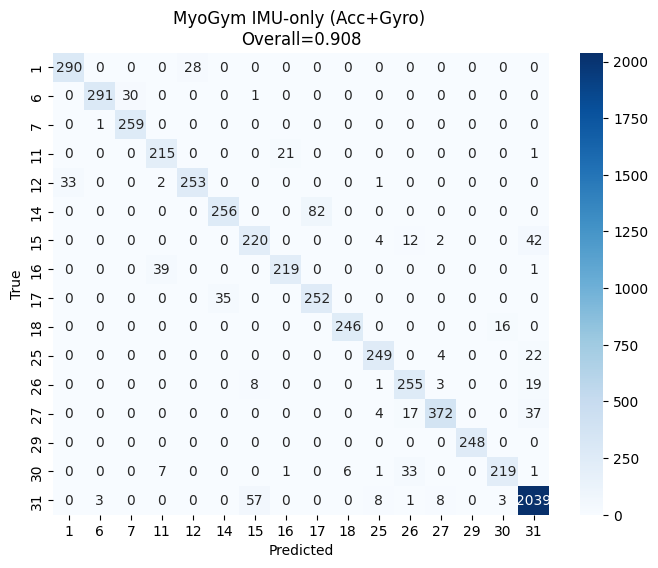

Classification Report:

              precision    recall  f1-score   support

           1       0.90      0.91      0.90       318
           6       0.99      0.90      0.94       322
           7       0.90      1.00      0.94       260
          11       0.82      0.91      0.86       237
          12       0.90      0.88      0.89       289
          14       0.88      0.76      0.81       338
          15       0.77      0.79      0.78       280
          16       0.91      0.85      0.88       259
          17       0.75      0.88      0.81       287
          18       0.98      0.94      0.96       262
          25       0.93      0.91      0.92       275
          26       0.80      0.89      0.84       286
          27       0.96      0.87      0.91       430
          29       1.00      1.00      1.00       248
          30       0.92      0.82      0.87       268
          31       0.94      0.96      0.95      2119

    accuracy                           0.91      6478
  

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

acc_overall = accuracy_score(y_true, y_pred)
classes = np.unique(y_true)
cm = confusion_matrix(y_true, y_pred, labels=classes)
report = classification_report(y_true, y_pred, labels=classes)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes,
            yticklabels=classes)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title(f"MyoGym IMU-only (Acc+Gyro) \nOverall={acc_overall:.3f}")
plt.show()

print("Classification Report:\n")
print(report)


# **Analisi per soggetto**

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.metrics import classification_report, confusion_matrix
from  sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score, f1_score, balanced_accuracy_score,
    classification_report, confusion_matrix
)

import pandas as pd

unique_subjects = np.unique(s)


rows = []
details = {}  # per salvare cm

for sub in unique_subjects:
    test_idx = (s == sub)
    train_idx = ~test_idx

    Xtr, Xte = X[train_idx], X[test_idx]
    ytr, yte = y[train_idx], y[test_idx]

    # Standardizzazione
    scaler = StandardScaler()
    Xtr = scaler.fit_transform(Xtr)
    Xte = scaler.transform(Xte)

    # SVM
    clf = SVC(kernel="rbf",
              C=1.0, gamma="scale",
              class_weight="balanced")
    clf.fit(Xtr, ytr)
    yhat = clf.predict(Xte)

    # Metriche soggetto
    acc = accuracy_score(yte, yhat)

    rows.append({
        "subject": int(sub),
        "n_test": int(len(yte)),
        "accuracy": float(acc),
    })


    # salvo la confusion matrix dei soggetti
    labels_sorted = np.sort(np.unique(np.concatenate([yte, yhat])))
    cm = confusion_matrix(yte, yhat, labels=labels_sorted)
    details[int(sub)] = {"labels": labels_sorted, "cm": cm, "accuracy" : acc}



# Results table
df = pd.DataFrame(rows).sort_values(by="accuracy", ascending=True).reset_index(drop=True)

print("\n=== LOSO accuracy per subject (worst → best) ===")
display(df)

worst = df.iloc[0]
best = df.iloc[-1]

print("\nWorst (most 'unlucky') subject:")
print(worst.to_dict())

print("\nBest subject:")
print(best.to_dict())


=== LOSO accuracy per subject (worst → best) ===


,subject,n_test,accuracy
0,1,722,0.628809
1,6,667,0.791604
2,7,656,0.911585
3,3,567,0.940035
4,10,501,0.940120
5,5,674,0.971810
6,2,817,0.971848
7,8,589,0.983022
8,9,773,0.988357
9,4,512,0.990234



Worst (most 'unlucky') subject:
{'subject': 1.0, 'n_test': 722.0, 'accuracy': 0.628808864265928}

Best subject:
{'subject': 4.0, 'n_test': 512.0, 'accuracy': 0.990234375}


Come si può notare dai risultati ottenuti, facendo un analisi per soggetto l'accuratezza varia da persona a persona. Vi sono infatti soggetti più "sfortunati" per cui le feature sono meno rappresentative.

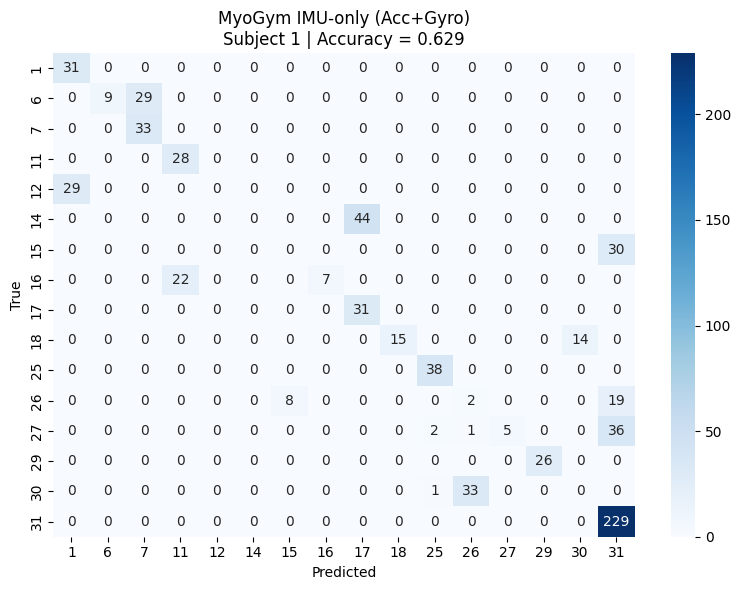

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report


# Soggetto da visualizzare
sub = 1

cm = details[sub]["cm"]
classes = details[sub]["labels"]
accuracy = details[sub]["accuracy"]

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=classes,
    yticklabels=classes
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title(f"MyoGym IMU-only (Acc+Gyro)\nSubject {sub} | Accuracy = {accuracy:.3f}")
plt.tight_layout()
plt.show()



# **Split 80/20**

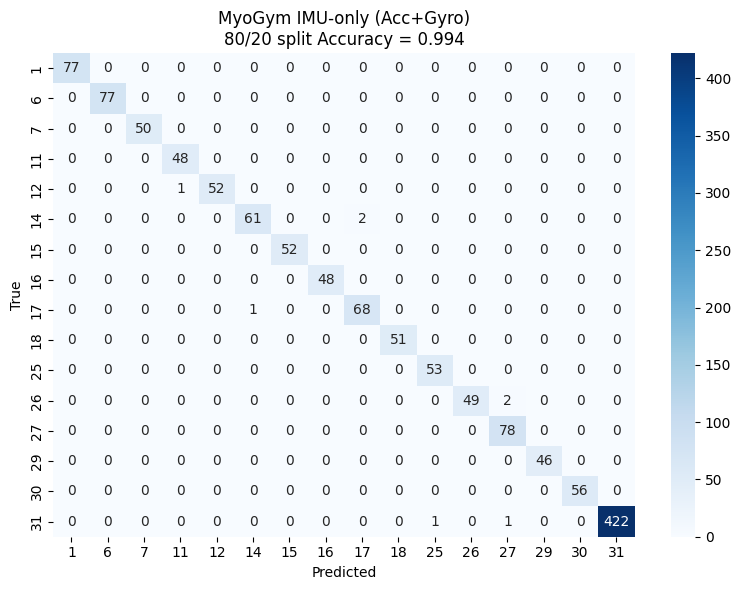

Classification Report:

              precision    recall  f1-score   support

           1       1.00      1.00      1.00        77
           6       1.00      1.00      1.00        77
           7       1.00      1.00      1.00        50
          11       0.98      1.00      0.99        48
          12       1.00      0.98      0.99        53
          14       0.98      0.97      0.98        63
          15       1.00      1.00      1.00        52
          16       1.00      1.00      1.00        48
          17       0.97      0.99      0.98        69
          18       1.00      1.00      1.00        51
          25       0.98      1.00      0.99        53
          26       1.00      0.96      0.98        51
          27       0.96      1.00      0.98        78
          29       1.00      1.00      1.00        46
          30       1.00      1.00      1.00        56
          31       1.00      1.00      1.00       424

    accuracy                           0.99      1296
  

In [ ]:
import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

data = sio.loadmat('MyoGym.mat')

accF  = data['features_acc']
gyroF = data['features_gyro']
labels = data['features_labels']

y_all = labels[:,0].astype(int).ravel()
subjects = labels[:,1].astype(int).ravel()

# classi originali da tenere
classes_keep = [1, 6, 7, 11, 12, 14, 15, 16, 17, 18, 25, 26, 27, 29, 30]

# classi curl da accorpare
curl_classes = [19, 20, 21, 22, 23, 24]
curl_label = 31   # nuova classe "BicepsCurl"

# maschera: tengo sia le classi buone sia i curl
mask = np.isin(y_all, classes_keep + curl_classes)

X = np.hstack([accF[mask], gyroF[mask]])
y = y_all[mask].copy()
s = subjects[mask]

# remapping curl → nuova classe
y[np.isin(y, curl_classes)] = curl_label


# Train / Test split 80/20
Xtr, Xte, ytr, yte = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42
)


# Standardization (fit on train only)
scaler = StandardScaler()
Xtr = scaler.fit_transform(Xtr)
Xte = scaler.transform(Xte)

# SVM
clf = SVC(kernel="rbf",
          C=1.0, gamma="scale",
          class_weight="balanced")

clf.fit(Xtr, ytr)
y_pred = clf.predict(Xte)

acc = accuracy_score(yte, y_pred)

classes = np.unique(y)
cm = confusion_matrix(yte, y_pred, labels=classes)

plt.figure(figsize=(8,6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=classes,
    yticklabels=classes
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title(f"MyoGym IMU-only (Acc+Gyro)\n80/20 split Accuracy = {acc:.3f}")
plt.tight_layout()
plt.show()

print("Classification Report:\n")
print(classification_report(yte, y_pred, labels=classes))


# **Feature Extraction**

In [ ]:
from scipy.stats import entropy

def box1_features_57(x, y, z):

    x = np.asarray(x, dtype=float).ravel()
    y = np.asarray(y, dtype=float).ravel()
    z = np.asarray(z, dtype=float).ravel()

    #dx = np.diff(x)
    #ddx = np.diff(dx)

    #var_x = np.var(x, ddof=1)
   # var_dx = np.var(dx, ddof=1) if dx.size > 1 else 0.0
    #var_ddx = np.var(ddx, ddof=1) if ddx.size > 1 else 0.0

    #activity = var_x
    #mobility = np.sqrt(var_dx / var_x)
    #mobility_dx = np.sqrt(var_ddx / var_dx)
    #complexity = (mobility_dx / mobility)


    # HjorthParameters(.) sono 3 (activity, mobility, complexity). Nel ReadMe ne viene usato solo 1 -> tengo Activity (variance) for each axis => 3 features total
    hjorth_activity = [np.var(x, ddof=1), np.var(y, ddof=1), np.var(z, ddof=1)]


    # Stats (15)
    stats = [
        np.std(x, ddof=1), np.std(y, ddof=1), np.std(z, ddof=1),
        np.mean(x), np.mean(y), np.mean(z),
        np.min(x), np.min(y), np.min(z),
        np.max(x), np.max(y), np.max(z),
        np.median(x), np.median(y), np.median(z),
    ]

    # Percentiles (18): 25,75,10,90,95,5 per ogni asse
    pct = []
    for p in (25, 75, 10, 90, 95, 5):
        pct.extend([np.percentile(x, p), np.percentile(y, p), np.percentile(z, p)])

    # Correlations (3)
    def corr(a, b):
        a = np.asarray(a, float).ravel()
        b = np.asarray(b, float).ravel()
        if np.std(a, ddof=1) == 0 or np.std(b, ddof=1) == 0:
            return 0.0
        return float(np.corrcoef(a, b)[0, 1])

    cxy, cxz, cyz = corr(x, y), corr(x, z), corr(y, z)

    # Upward zero crossings (3)
    zcX = int(np.sum((x[1:] >= 0) & (x[:-1] <= 0)))
    zcY = int(np.sum((y[1:] >= 0) & (y[:-1] <= 0)))
    zcZ = int(np.sum((z[1:] >= 0) & (x[:-1] <= 0)))

    # Upward mean crossings (3)
    mx, my, mz = np.mean(x), np.mean(y), np.mean(z)
    mcX = int(np.sum((x[1:] >= mx) & (x[:-1] <= mx)))
    mcY = int(np.sum((y[1:] >= my) & (y[:-1] <= my)))
    mcZ = int(np.sum((z[1:] >= mz) & (z[:-1] <= mz)))

    # FFT sums (9): abs(fft(.,200)) e z-score spectrum
    def _std_safe(x, ddof=1):
        s = np.std(x, ddof=ddof)
        return s if (s != 0 and np.isfinite(s)) else 1.0

    def fft_zscore_sums(sig):
        X = np.abs(np.fft.fft(sig, 200))
        X = (X - np.mean(X)) / _std_safe(X, ddof=1)
        s1 = float(np.sum(X[0:1]))      # bin1
        s15 = float(np.sum(X[0:5]))     # bins1..5
        s610 = float(np.sum(X[5:10]))   # bins6..10
        return s1, s15, s610

    fx = fft_zscore_sums(x)
    fy = fft_zscore_sums(y)
    fz = fft_zscore_sums(z)
    fft_sums = [fx[0], fy[0], fz[0], fx[1], fy[1], fz[1], fx[2], fy[2], fz[2]]


    # Entropy (3)
    def entropy_feat(sig, bins=100):
      sig = np.asarray(sig, float).ravel()
      if sig.size == 0:
            return 0.0
      hist, _ = np.histogram(sig, bins=bins, density=True)
      hist = hist[hist > 0]
      return float(entropy(hist, base=2))

    ex = entropy_feat(x)
    ey = entropy_feat(y)
    ez = entropy_feat(z)

    feat = hjorth_activity + stats + pct + [cxy, cxz, cyz] + \
           [zcX, zcY, zcZ, mcX, mcY, mcZ] + fft_sums + [ex, ey, ez]

    feat = np.asarray(feat, dtype=float)
    return feat

In [ ]:
def compare_row(mat_path, r=0):
    import numpy as np
    import scipy.io as sio

    data = sio.loadmat(mat_path)

    raw = data["raw_data"]
    raw_labels = data["raw_data_labels"]

    accF = data["features_acc"]
    gyroF = data["features_gyro"]
    labF = data["features_labels"]

    # parametri finestra
    FS = 50
    WIN_N = 4 * FS      # 200 campioni
    STEP_N = 1 * FS     # 50 campioni

    ACC_COLS = (10, 11, 12)   # MATLAB 11-13
    GYRO_COLS = (14, 15, 16)  # MATLAB 15-17

    print(f"Testing row r={r}")
    print(f"Feature label: class={int(labF[r,0])}, subject={int(labF[r,1])}")

    # Costruzione finestre raw dall'inizio
    starts = np.arange(0, raw.shape[0] - WIN_N + 1, STEP_N) # [0      50     100 ... 2016700 2016750 2016800]


    st = starts[r]
    en = st + WIN_N

    print(f"Using raw window [{st}:{en}]")

    # Estrazione segnali
    acc = raw[st:en, list(ACC_COLS)]
    gyr = raw[st:en, list(GYRO_COLS)]

    print(f"\nAccelerometer shape: {acc.shape}")
    print(f"Gyroscope shape: {gyr.shape}")

    # Calcolo feature BOX1
    acc_feat = box1_features_57(acc[:,0], acc[:,1], acc[:,2])
    gyr_feat = box1_features_57(gyr[:,0], gyr[:,1], gyr[:,2])


    # Confronto
    target_acc = accF[r,:].astype(float)
    target_gyr = gyroF[r,:].astype(float)

    diff_acc = acc_feat - target_acc
    diff_gyr = gyr_feat - target_gyr

    print("\nAll 57 ACC features: [provided | computed | diff]")
    for i in range(57):
        print(f"{i+1:2d}: {target_acc[i]: .6g} | {acc_feat[i]: .6g} | {diff_acc[i]: .6g}")

    print("\nAll 57 GYRO features: [provided | computed | diff]")
    for i in range(57):
        print(f"{i+1:2d}: {target_gyr[i]: .6g} | {gyr_feat[i]: .6g} | {diff_gyr[i]: .6g}")

   # return {
    #    "row": r,
    #    "raw_start": st,
    #    "acc_diff": diff_acc,
    #    "gyro_diff": diff_gyr
    #}

# Find the name of the uploaded .mat file
mat_name = next(iter(uploaded.keys()))

compare_row(mat_name, r=0)

Testing row r=0
Feature label: class=99, subject=1
Using raw window [0:200]

Accelerometer shape: (200, 3)
Gyroscope shape: (200, 3)

All 57 ACC features: [provided | computed | diff]
 1:  0.262552 |  0.00467179 | -0.25788
 2:  0.101335 |  0.00631249 | -0.0950226
 3:  0.657392 |  0.0123696 | -0.645022
 4:  0.0683505 |  0.0683505 | -2.77556e-17
 5:  0.0794512 |  0.0794512 |  1.38778e-17
 6:  0.111219 |  0.111219 |  8.32667e-17
 7:  0.244336 |  0.244336 |  8.32667e-17
 8:  0.986545 |  0.986545 |  2.22045e-16
 9: -0.0200708 | -0.0200708 | -6.93889e-18
10:  0.00293 |  0.00293 |  0
11:  0.527344 |  0.527344 |  0
12: -0.536621 | -0.536621 |  0
13:  0.597656 |  0.597656 |  0
14:  1.34717 |  1.34717 |  0
15:  0.361816 |  0.361816 |  0
16:  0.247314 |  0.247314 |  0
17:  0.98584 |  0.98584 |  0
18: -0.016846 | -0.016846 |  0
19:  0.218995 |  0.219361 |  0.00036625
20:  0.962646 |  0.962769 |  0.00012225
21: -0.056641 | -0.0556645 |  0.0009765
22:  0.272949 |  0.272949 |  0
23:  1.01196 |  1.011

# **Addestramento utilizzando le feature calcolate**

**Feature CALCOLATE senza Hjorth e entropia split 80/20**

Siccome non so quali finestre sono state eliminate dagli autori dal dataset iniziale, tengo tutte le finestre e addestro il modello.

0/40337


/tmp/ipython-input-2515593259.py:18: RuntimeWarning: invalid value encountered in scalar divide
  mobility_dx = np.sqrt(var_ddx / var_dx)
/tmp/ipython-input-2515593259.py:17: RuntimeWarning: invalid value encountered in scalar divide
  mobility = np.sqrt(var_dx / var_x)


2000/40337
4000/40337
6000/40337
8000/40337
10000/40337
12000/40337
14000/40337
16000/40337
18000/40337
20000/40337
22000/40337
24000/40337
26000/40337
28000/40337
30000/40337
32000/40337
34000/40337
36000/40337
38000/40337
40000/40337
X_all: (40337, 102) y_win: (40337,) s_win: (40337,)
Final shapes: (6476, 102) (6476,)
Classes: [ 1  6  7 11 12 14 15 16 17 18 25 26 27 29 30 31]


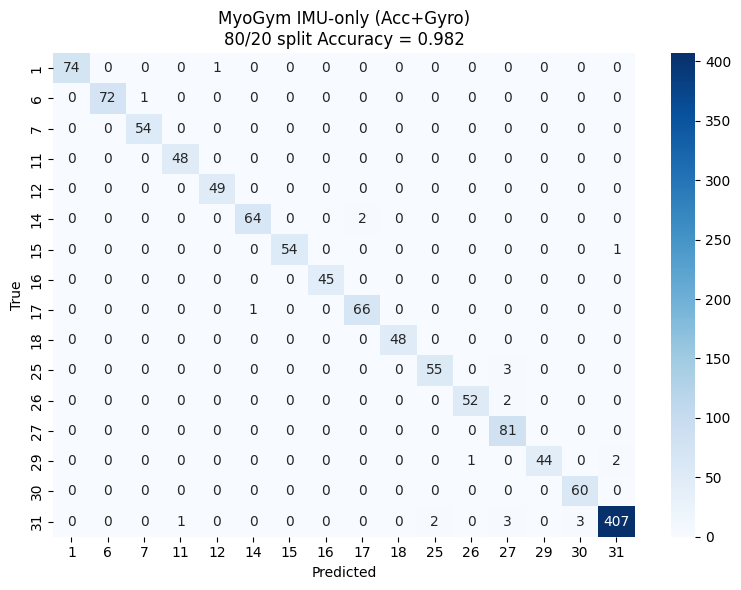

Classification Report:

              precision    recall  f1-score   support

           1       1.00      0.99      0.99        75
           6       1.00      0.99      0.99        73
           7       0.98      1.00      0.99        54
          11       0.98      1.00      0.99        48
          12       0.98      1.00      0.99        49
          14       0.98      0.97      0.98        66
          15       1.00      0.98      0.99        55
          16       1.00      1.00      1.00        45
          17       0.97      0.99      0.98        67
          18       1.00      1.00      1.00        48
          25       0.96      0.95      0.96        58
          26       0.98      0.96      0.97        54
          27       0.91      1.00      0.95        81
          29       1.00      0.94      0.97        47
          30       0.95      1.00      0.98        60
          31       0.99      0.98      0.99       416

    accuracy                           0.98      1296
  

In [ ]:
import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import numpy as np

data = sio.loadmat("MyoGym.mat")
raw = data["raw_data"]
raw_labels = data["raw_data_labels"]

lab_raw = raw_labels[:, 0].astype(int).ravel()
sub_raw = raw_labels[:, 1].astype(int).ravel()


ACC_COLS = (10, 11, 12)
GYRO_COLS = (14, 15, 16)

FS = 50
WIN_N = 4 * FS    # 200
STEP_N = 1 * FS   # 50

starts = np.arange(0, raw.shape[0] - WIN_N + 1, STEP_N).astype(int)
N = len(starts)

# Indici per tenere solo 51 feature su 57 (elimino prime 3 e ultime 3)
keep_51 = np.r_[3:54]  # 3..53 inclusi -> 51


# LABEL PER FINESTRA (NESSUNO SCARTO)
# scelgo la label al PRIMO campione della finestra
y_win = lab_raw[starts]
s_win = sub_raw[starts]


# CALCOLO FEATURE SU TUTTE LE FINESTRE
def compute_feature_from_start(st):
    en = st + WIN_N

    acc = raw[st:en, list(ACC_COLS)]
    gyr = raw[st:en, list(GYRO_COLS)]

    acc_57 = box1_features_57(acc[:, 0], acc[:, 1], acc[:, 2])
    gyr_57 = box1_features_57(gyr[:, 0], gyr[:, 1], gyr[:, 2])

    # rimuovo prime 3 e ultime 3 -> 51 per sensore
    acc_51 = acc_57[keep_51]
    gyr_51 = gyr_57[keep_51]

    return np.hstack([acc_51, gyr_51])  # (102,)

X_all = np.zeros((N, 102), dtype=float)

for i, st in enumerate(starts):
    if i % 2000 == 0:
        print(f"{i}/{N}")
    X_all[i, :] = compute_feature_from_start(int(st))

print("X_all:", X_all.shape, "y_win:", y_win.shape, "s_win:", s_win.shape)


# FILTRO CLASSI + ACCORPAMENTO CURL

classes_keep = [1, 6, 7, 11, 12, 14, 15, 16, 17, 18, 25, 26, 27, 29, 30]
curl_classes = [19, 20, 21, 22, 23, 24]
curl_label = 31
NULL_LABEL = 99

mask = np.isin(y_win, classes_keep + curl_classes) & (y_win != NULL_LABEL)

X_rec = X_all[mask]
y_rec = y_win[mask].copy()
s_rec = s_win[mask].copy()

y_rec[np.isin(y_rec, curl_classes)] = curl_label

print("Final shapes:", X_rec.shape, y_rec.shape)
print("Classes:", np.unique(y_rec))

Xtr, Xte, ytr, yte = train_test_split(
    X_rec, y_rec,
    test_size=0.20,
    random_state=42
)

scaler = StandardScaler()
Xtr = scaler.fit_transform(Xtr)
Xte = scaler.transform(Xte)

clf = SVC(kernel="rbf", C=1.0, gamma="scale", class_weight="balanced")
clf.fit(Xtr, ytr)

y_pred = clf.predict(Xte)
acc = accuracy_score(yte, y_pred)

classes = np.unique(y_rec)
cm = confusion_matrix(yte, y_pred, labels=classes)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title(f"MyoGym IMU-only (Acc+Gyro)\n80/20 split Accuracy = {acc:.3f}")
plt.tight_layout()
plt.show()

print("Classification Report:\n")
print(classification_report(yte, y_pred, labels=classes))


**Feature MyoGym senza Hjorth e entropia split 80/20**

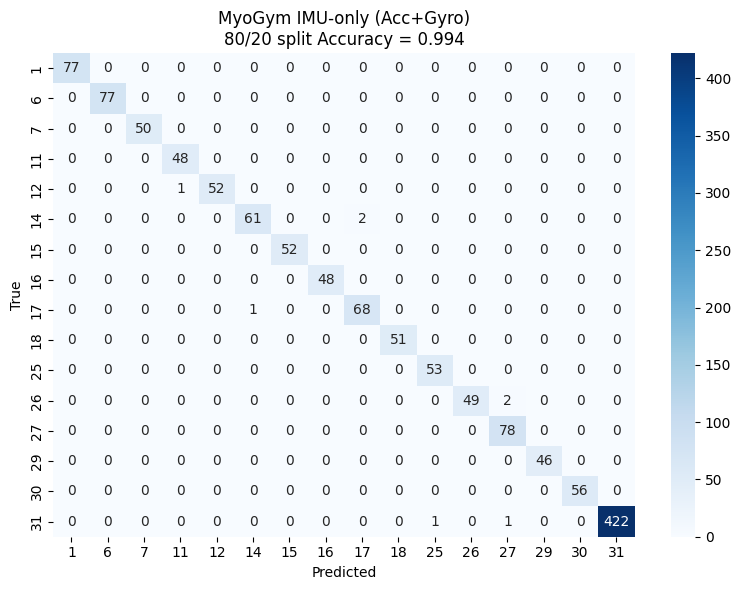

Classification Report:

              precision    recall  f1-score   support

           1       1.00      1.00      1.00        77
           6       1.00      1.00      1.00        77
           7       1.00      1.00      1.00        50
          11       0.98      1.00      0.99        48
          12       1.00      0.98      0.99        53
          14       0.98      0.97      0.98        63
          15       1.00      1.00      1.00        52
          16       1.00      1.00      1.00        48
          17       0.97      0.99      0.98        69
          18       1.00      1.00      1.00        51
          25       0.98      1.00      0.99        53
          26       1.00      0.96      0.98        51
          27       0.96      1.00      0.98        78
          29       1.00      1.00      1.00        46
          30       1.00      1.00      1.00        56
          31       1.00      1.00      1.00       424

    accuracy                           0.99      1296
  

In [ ]:
import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

data = sio.loadmat('MyoGym.mat')

accF  = data['features_acc']
gyroF = data['features_gyro']
labels = data['features_labels']

# Indici per tenere solo 51 feature su 57 (elimino prime 3 e ultime 3)
keep_51 = np.r_[3:54]  # 3..53 inclusi -> 51

# rimuovo prime 3 e ultime 3 -> 51 per sensore
accF51 = accF[:, keep_51]
gyrF51 = gyroF[:, keep_51]

y_all = labels[:,0].astype(int).ravel()
subjects = labels[:,1].astype(int).ravel()

# classi originali da tenere
classes_keep = [1, 6, 7, 11, 12, 14, 15, 16, 17, 18, 25, 26, 27, 29, 30]

# classi curl da accorpare
curl_classes = [19, 20, 21, 22, 23, 24]
curl_label = 31   # nuova classe "BicepsCurl"

# maschera: tengo sia le classi buone sia i curl
mask = np.isin(y_all, classes_keep + curl_classes)

X = np.hstack([accF51[mask], gyrF51[mask]])
y = y_all[mask].copy()
s = subjects[mask].copy()

# remapping curl → nuova classe
y[np.isin(y, curl_classes)] = curl_label


# Train / Test split 80/20
Xtr, Xte, ytr, yte = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42
)


# Standardization (fit on train only)
scaler = StandardScaler()
Xtr = scaler.fit_transform(Xtr)
Xte = scaler.transform(Xte)

# SVM
clf = SVC(kernel="rbf",
          C=1.0, gamma="scale",
          class_weight="balanced")

clf.fit(Xtr, ytr)
y_pred = clf.predict(Xte)

acc = accuracy_score(yte, y_pred)

classes = np.unique(y)
cm = confusion_matrix(yte, y_pred, labels=classes)

plt.figure(figsize=(8,6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=classes,
    yticklabels=classes
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title(f"MyoGym IMU-only (Acc+Gyro)\n80/20 split Accuracy = {acc:.3f}")
plt.tight_layout()
plt.show()

print("Classification Report:\n")
print(classification_report(yte, y_pred, labels=classes))

**LOSO feature CALCOLATE**

Subject 1 done. Test samples: 721 | Acc: 0.653
Subject 2 done. Test samples: 817 | Acc: 0.963
Subject 3 done. Test samples: 567 | Acc: 0.892
Subject 4 done. Test samples: 512 | Acc: 0.965
Subject 5 done. Test samples: 674 | Acc: 0.960
Subject 6 done. Test samples: 667 | Acc: 0.772
Subject 7 done. Test samples: 656 | Acc: 0.905
Subject 8 done. Test samples: 588 | Acc: 0.963
Subject 9 done. Test samples: 773 | Acc: 0.968
Subject 10 done. Test samples: 501 | Acc: 0.932

=== LOSO Overall accuracy ===
0.8948

=== LOSO per-subject accuracy (worst → best) ===


,subject,n_test,accuracy
0,1,721,0.653259
1,6,667,0.772114
2,3,567,0.892416
3,7,656,0.905488
4,10,501,0.932136
5,5,674,0.959941
6,8,588,0.962585
7,2,817,0.963280
8,4,512,0.964844
9,9,773,0.967658


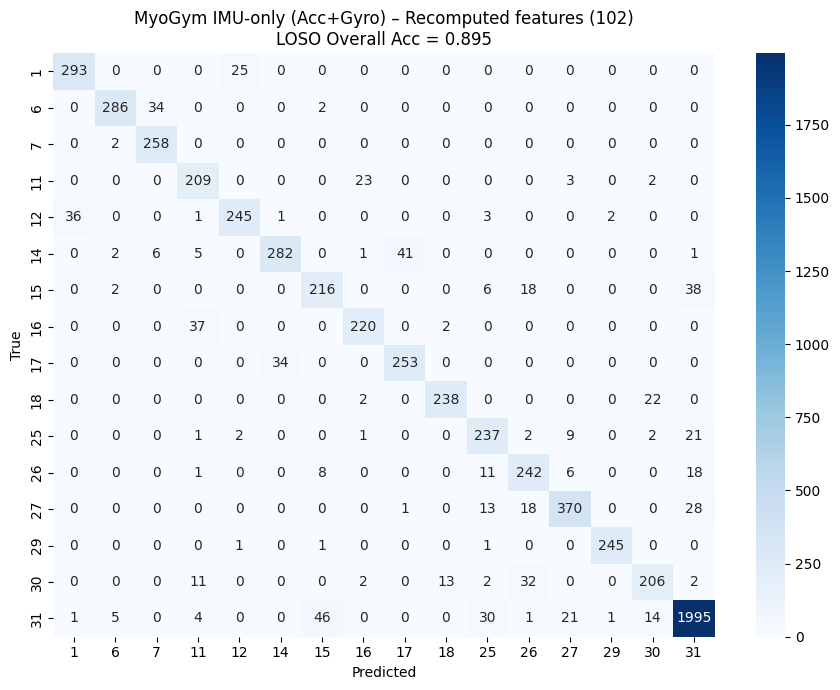


Classification Report (LOSO, aggregated):

              precision    recall  f1-score   support

           1       0.89      0.92      0.90       318
           6       0.96      0.89      0.92       322
           7       0.87      0.99      0.92       260
          11       0.78      0.88      0.83       237
          12       0.90      0.85      0.87       288
          14       0.89      0.83      0.86       338
          15       0.79      0.77      0.78       280
          16       0.88      0.85      0.87       259
          17       0.86      0.88      0.87       287
          18       0.94      0.91      0.92       262
          25       0.78      0.86      0.82       275
          26       0.77      0.85      0.81       286
          27       0.90      0.86      0.88       430
          29       0.99      0.99      0.99       248
          30       0.84      0.77      0.80       268
          31       0.95      0.94      0.95      2118

    accuracy                        

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import pandas as pd

# Modello
clf_params = dict(kernel="rbf", C=1.0, gamma="scale", class_weight="balanced")

classes = np.sort(np.unique(y_rec))
subjects = np.sort(np.unique(s_rec))

y_true_all = []
y_pred_all = []

rows = []

for sub in subjects:
    test_idx = (s_rec == sub)
    train_idx = ~test_idx

    Xtr, Xte = X_rec[train_idx], X_rec[test_idx]
    ytr, yte = y_rec[train_idx], y_rec[test_idx]

    # Standardizzazione: fit SOLO su train
    scaler = StandardScaler()
    Xtr = scaler.fit_transform(Xtr)
    Xte = scaler.transform(Xte)

    clf = SVC(**clf_params)
    clf.fit(Xtr, ytr)

    yhat = clf.predict(Xte)

    acc_sub = accuracy_score(yte, yhat)

    rows.append({
        "subject": int(sub),
        "n_test": int(len(yte)),
        "accuracy": float(acc_sub)
    })

    y_true_all.append(yte)
    y_pred_all.append(yhat)

    print(f"Subject {sub} done. Test samples: {len(yte)} | Acc: {acc_sub:.3f}")


y_true_all = np.concatenate(y_true_all)
y_pred_all = np.concatenate(y_pred_all)

acc_overall = accuracy_score(y_true_all, y_pred_all)
print("\n=== LOSO Overall accuracy ===")
print(f"{acc_overall:.4f}")

# tabella per-soggetto (peggiori in alto)
df = pd.DataFrame(rows).sort_values("accuracy", ascending=True).reset_index(drop=True)
print("\n=== LOSO per-subject accuracy (worst → best) ===")
display(df)

# confusion matrix complessiva
cm = confusion_matrix(y_true_all, y_pred_all, labels=classes)

plt.figure(figsize=(9,7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title(f"MyoGym IMU-only (Acc+Gyro) – Recomputed features (102)\nLOSO Overall Acc = {acc_overall:.3f}")
plt.tight_layout()
plt.show()

print("\nClassification Report (LOSO, aggregated):\n")
print(classification_report(y_true_all, y_pred_all, labels=classes))


**LOSO feature MyoGym senza Hjorth e entropia**

Subject 1 done. Test samples: 722 | Acc: 0.658
Subject 2 done. Test samples: 817 | Acc: 0.976
Subject 3 done. Test samples: 567 | Acc: 0.937
Subject 4 done. Test samples: 512 | Acc: 0.992
Subject 5 done. Test samples: 674 | Acc: 0.975
Subject 6 done. Test samples: 667 | Acc: 0.798
Subject 7 done. Test samples: 656 | Acc: 0.910
Subject 8 done. Test samples: 589 | Acc: 0.978
Subject 9 done. Test samples: 773 | Acc: 0.987
Subject 10 done. Test samples: 501 | Acc: 0.934

=== LOSO Overall accuracy ===
0.9114

=== LOSO per-subject accuracy (worst → best) ===


,subject,n_test,accuracy
0,1,722,0.657895
1,6,667,0.797601
2,7,656,0.910061
3,10,501,0.934132
4,3,567,0.936508
5,5,674,0.974777
6,2,817,0.975520
7,8,589,0.977929
8,9,773,0.987063
9,4,512,0.992188


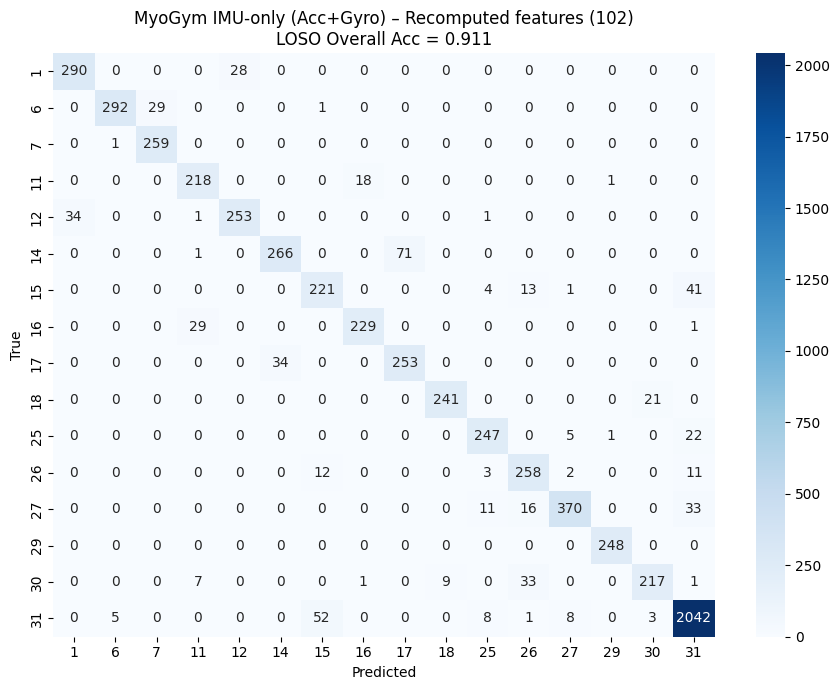


Classification Report (LOSO, aggregated):

              precision    recall  f1-score   support

           1       0.90      0.91      0.90       318
           6       0.98      0.91      0.94       322
           7       0.90      1.00      0.95       260
          11       0.85      0.92      0.88       237
          12       0.90      0.88      0.89       289
          14       0.89      0.79      0.83       338
          15       0.77      0.79      0.78       280
          16       0.92      0.88      0.90       259
          17       0.78      0.88      0.83       287
          18       0.96      0.92      0.94       262
          25       0.90      0.90      0.90       275
          26       0.80      0.90      0.85       286
          27       0.96      0.86      0.91       430
          29       0.99      1.00      1.00       248
          30       0.90      0.81      0.85       268
          31       0.95      0.96      0.96      2119

    accuracy                        

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import pandas as pd

# Modello
clf_params = dict(kernel="rbf", C=1.0, gamma="scale", class_weight="balanced")

classes = np.sort(np.unique(y))
subjects = np.sort(np.unique(s))

y_true_all = []
y_pred_all = []

rows = []

for sub in subjects:
    test_idx = (s == sub)
    train_idx = ~test_idx

    Xtr, Xte = X[train_idx], X[test_idx]
    ytr, yte = y[train_idx], y[test_idx]

    # Standardizzazione: fit SOLO su train
    scaler = StandardScaler()
    Xtr = scaler.fit_transform(Xtr)
    Xte = scaler.transform(Xte)

    clf = SVC(**clf_params)
    clf.fit(Xtr, ytr)

    yhat = clf.predict(Xte)

    acc_sub = accuracy_score(yte, yhat)

    rows.append({
        "subject": int(sub),
        "n_test": int(len(yte)),
        "accuracy": float(acc_sub)
    })

    y_true_all.append(yte)
    y_pred_all.append(yhat)

    print(f"Subject {sub} done. Test samples: {len(yte)} | Acc: {acc_sub:.3f}")


y_true_all = np.concatenate(y_true_all)
y_pred_all = np.concatenate(y_pred_all)

acc_overall = accuracy_score(y_true_all, y_pred_all)
print("\n=== LOSO Overall accuracy ===")
print(f"{acc_overall:.4f}")

# tabella per-soggetto (peggiori in alto)
df = pd.DataFrame(rows).sort_values("accuracy", ascending=True).reset_index(drop=True)
print("\n=== LOSO per-subject accuracy (worst → best) ===")
display(df)

# confusion matrix complessiva
cm = confusion_matrix(y_true_all, y_pred_all, labels=classes)

plt.figure(figsize=(9,7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title(f"MyoGym IMU-only (Acc+Gyro) – Provided features (102)\nLOSO Overall Acc = {acc_overall:.3f}")
plt.tight_layout()
plt.show()

print("\nClassification Report (LOSO, aggregated):\n")
print(classification_report(y_true_all, y_pred_all, labels=classes))

# **Preparazione dati per Classification Learner**

In [ ]:
import numpy as np
import scipy.io as sio

data = sio.loadmat("MyoGym.mat")

accF   = data["features_acc"]      # (N,57)
gyroF  = data["features_gyro"]     # (N,57)
labels = data["features_labels"]   # (N,2)

X = np.hstack([accF, gyroF])       # (N,114)  <-- tutte le feature
y = labels[:, 0].astype(int).ravel()
s = labels[:, 1].astype(int).ravel()

classes_keep = [1, 6, 7, 11, 12, 14, 15, 16, 17, 18, 25, 26, 27, 29, 30]
curl_classes = [19, 20, 21, 22, 23, 24]
curl_label   = 31
NULL_LABEL   = 99

mask = np.isin(y, classes_keep + curl_classes) & (y != NULL_LABEL)

X = X[mask]
y = y[mask]
s = s[mask]

y[np.isin(y, curl_classes)] = curl_label

print("Final dataset:", X.shape, y.shape)
print("Classes:", np.unique(y))


Final dataset: (6478, 114) (6478,)
Classes: [ 1  6  7 11 12 14 15 16 17 18 25 26 27 29 30 31]


In [ ]:
sio.savemat("dataset_for_classification_learner.mat", {
    "X": X.astype(float),
    "y": y.astype(int),
    "s": s.astype(int),
})
